/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



================ Training Baseline ================
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

================ Training L1/L2 Regularization ================
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

================ Training Dropout Regularization ================
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

================ PERFORMANCE COMPARISON ================
                                 MAE           MSE           RMSE  R2 Score
Baseline                93962.128620  1.382704e+10  117588.438689  0.887615
L1/L2 Regularization    82230.934845  1.047730e+10  102358.703758  0.914841
Dropout Regularization  84983.328922  1.128197e+10  106216.597377  0.908301


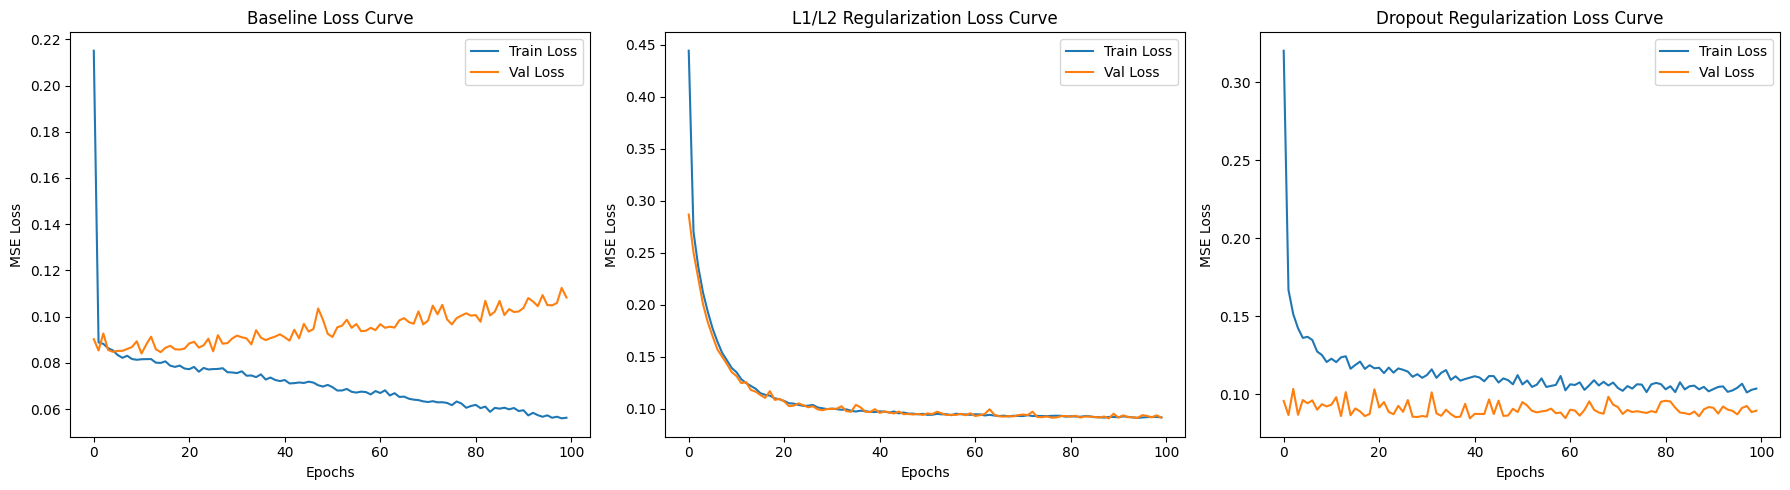

In [5]:
#kalyani_23070521036
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l1_l2

# =====================================================================
# 1. LOAD DATASET & PREPROCESSING
# =====================================================================
# Load the housing.csv dataset directly
df = pd.read_csv("/content/housing.csv")

# Drop 'Address' or non-numeric textual columns if present
if 'Address' in df.columns:
    df = df.drop(columns=['Address'])

# Separate features (X) and target (y)
X = df.drop(columns=['Price']).values
y = df['Price'].values.reshape(-1, 1)

# Split dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features and targets for numerical stability during gradient descent
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

input_dim = X_train_scaled.shape[1]

# =====================================================================
# 2. DEFINE MODEL ARCHITECTURES
# =====================================================================

# Model A: Baseline Model (No Regularization)
def build_baseline_model():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Model B: L1 & L2 Regularized Model
def build_l1_l2_model():
    model = Sequential([
        Dense(128, activation='relu', kernel_regularizer=l1_l2(l1=1e-4, l2=1e-3), input_shape=(input_dim,)),
        Dense(64, activation='relu', kernel_regularizer=l1_l2(l1=1e-4, l2=1e-3)),
        Dense(32, activation='relu', kernel_regularizer=l1_l2(l1=1e-4, l2=1e-3)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Model C: Dropout Regularized Model
def build_dropout_model():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# =====================================================================
# 3. TRAIN AND EVALUATE MODELS
# =====================================================================
models = {
    "Baseline": build_baseline_model(),
    "L1/L2 Regularization": build_l1_l2_model(),
    "Dropout Regularization": build_dropout_model()
}

histories = {}
results = {}

EPOCHS = 100
BATCH_SIZE = 32

for name, model in models.items():
    print(f"\n================ Training {name} ================")
    history = model.fit(
        X_train_scaled, y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        verbose=0
    )
    histories[name] = history

    # Evaluate model on normalized test set
    preds_scaled = model.predict(X_test_scaled)

    # Inverse transform to retrieve real dollar values
    y_pred = scaler_y.inverse_transform(preds_scaled)
    y_true = y_test

    # Metrics computation
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r2}

# =====================================================================
# 4. SUMMARY COMPARISON TABLE
# =====================================================================
df_results = pd.DataFrame(results).T
print("\n================ PERFORMANCE COMPARISON ================")
print(df_results)

# =====================================================================
# 5. VISUALIZE LOSS CURVES (TRAIN VS VALIDATION)
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, history) in enumerate(histories.items()):
    axes[i].plot(history.history['loss'], label='Train Loss')
    axes[i].plot(history.history['val_loss'], label='Val Loss')
    axes[i].set_title(f"{name} Loss Curve")
    axes[i].set_xlabel('Epochs')
    axes[i].set_ylabel('MSE Loss')
    axes[i].legend()

plt.tight_layout()
plt.show()